# Hugging Face classification

resource: https://www.learnhuggingface.com/notebooks/hugging_face_text_classification_tutorial

setup: https://www.learnhuggingface.com/extras/setup

Need to use a GPU on Colb which can be done by going to Runtime and selecting change runtime type and selecting a GPU option


In [71]:
# import necessary libraries
# Install dependencies (this is mostly for Google Colab, as the other dependences are available by default in Colab)
try:
  import datasets, evaluate, accelerate
  import gradio as gr
except ModuleNotFoundError:
  !pip install -U datasets evaluate accelerate gradio # -U stands for "upgrade" so we'll get the latest version by default
  import datasets, evaluate, accelerate
  import gradio as gr

import random

import numpy as np
import pandas as pd

import torch
import transformers

print(f"Using transformers version: {transformers.__version__}")
print(f"Using datasets version: {datasets.__version__}")
print(f"Using torch version: {torch.__version__}")

Using transformers version: 5.0.0
Using datasets version: 4.8.5
Using torch version: 2.11.0+cu128


In [72]:
# dataset for food and not_food to be used to make the classification model

from datasets import load_dataset

dataset = load_dataset("mrdbourke/learn_hf_food_not_food_image_captions")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [73]:
# What features exits?
dataset.column_names

{'train': ['text', 'label']}

In [74]:
# Access training split

from datasets import load_dataset
# Re-load the dataset to ensure 'dataset' is a DatasetDict
dataset = load_dataset("mrdbourke/learn_hf_food_not_food_image_captions")

dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 250
})

In [75]:
# view both labels
dataset["train"].unique("label")

['food', 'not_food']

In [76]:
# view some random samples
random_indices = random.sample(range(len(dataset["train"])), 5)
print(random_indices)

random_samples = dataset["train"][random_indices]
print(f"Random samples from dataset:\n")
for text, label in zip(random_samples["text"], random_samples["label"]):
  print(f"text: {text} | label: {label}")

[163, 28, 6, 189, 70]
Random samples from dataset:

text: Set of spatulas kept in a holder | label: not_food
text: Mouthwatering paneer tikka masala, featuring juicy paneer in a rich tomato-based sauce, garnished with fresh coriander leaves. | label: food
text: Pair of reading glasses left open on a book | label: not_food
text: Set of board games stacked on a shelf | label: not_food
text: Two handfuls of bananas in a fruit bowl with grapes on the side, the fruit bowl is blue | label: food


In [77]:
# check the count of each label
from collections import Counter

Counter(dataset["train"]["label"])

Counter({'food': 125, 'not_food': 125})

In [78]:
# use random samples to create a dataset which creats a DataFrame
fnf_df = pd.DataFrame(dataset["train"])
fnf_df.sample(5)

,text,label
142,A slice of pizza with a generous amount of shr...,food
6,Pair of reading glasses left open on a book,not_food
97,Telescope positioned on a balcony,not_food
60,A close-up of a family playing a board game wi...,not_food
112,Rich and spicy lamb rogan josh with yogurt gar...,food


In [79]:
# creating a DataFrame with the counts of both labels
fnf_df["label"].value_counts()

,count
label,
food,125
not_food,125


Tokenize the text by using numbers for the machine to read and create a training split alongside a test split to train the machine and test it

In [80]:
# map labels to numeric values

id2label = {0: "not_food", 1: "food"}
label2id = {"not_food": 0, "food": 1}

print(f"Label to ID mapping: {label2id}")
print(f"ID to Label mapping: {id2label}")

Label to ID mapping: {'not_food': 0, 'food': 1}
ID to Label mapping: {0: 'not_food', 1: 'food'}


In [81]:
# Create mappings programmatically from dataset

id2label = {idx: label for idx, label in enumerate(dataset["train"].unique("label")[::-1])}
label2id = label2id = {label: idx for idx, label in id2label.items()}

print(f"Label to ID mapping: {label2id}")
print(f"ID to Label mapping: {id2label}")

Label to ID mapping: {'not_food': 0, 'food': 1}
ID to Label mapping: {0: 'not_food', 1: 'food'}


In [82]:
# Turn labels into 0 for not_food and 1 for food
def map_labels_to_number(example):
  example["label"] = label2id[example["label"]]
  return example

example_sample = {"text": "This is a sentence about chicken.", "label": "food"}

# Test the function
map_labels_to_number(example_sample)

{'text': 'This is a sentence about chicken.', 'label': 1}

In [83]:
# Map our dataset labels to numbers
dataset = dataset["train"].map(map_labels_to_number)
dataset[:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [84]:
dataset.shuffle()[:5]

{'text': ['Set of oven mitts hanging on a hook',
  'Set of cookie cutters collected in a jar',
  'Pizza with a dessert twist, featuring a sweet Nutella base and fresh strawberries on top',
  'Set of binoculars placed on a table',
  'Two handfuls of bananas in a fruit bowl with grapes on the side, the fruit bowl is blue'],
 'label': [0, 0, 1, 0, 1]}

split using dataset.train_test_split: https://huggingface.co/docs/datasets/v2.20.0/en/package_reference/main_classes#datasets.Dataset.train_test_split

In [85]:
# Create train/test splits
dataset = dataset.train_test_split(test_size=0.2, seed=42) # seed isn't needed, without it you will get different splits each time you run the cell
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [86]:
random_idx_train = random.randint(0, len(dataset["train"]))
random_sample_train = dataset["train"][random_idx_train]
random_sample_train

{'text': 'Set of dumbbells stacked in a gym', 'label': 0}

In [87]:
random_idx_test = random.randint(0, len(dataset["test"]))
random_sample_test = dataset["test"][random_idx_test]
random_sample_test

{'text': 'Two handfuls of bananas in a fruit bowl with grapes on the side, the fruit bowl is blue',
 'label': 1}

all models: https://huggingface.co/models
tokenizer: https://huggingface.co/distilbert/distilbert-base-uncased
from_pretrained: https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes

In [88]:
from transformers import AutoTokenizer

# uses fast tokenization which is supported by tokenziers library and implemented in Rust by default, and python if unavailable
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path="distilbert/distilbert-base-uncased",
                                          use_fast=True)
tokenizer

BertTokenizer(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [89]:
# Test out tokenizer
tokenizer("I love pizza")

{'input_ids': [101, 1045, 2293, 10733, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

In [90]:
# Get the length of the vocabulary
length_of_tokenizer_vocab = len(tokenizer.vocab)
print(f"Length of tokenizer vocabulary: {length_of_tokenizer_vocab}")

# Get the maximum sequence length the tokenizer can handle
max_tokenizer_input_sequence_length = tokenizer.model_max_length
print(f"Max tokenizer input sequence length: {max_tokenizer_input_sequence_length}")

Length of tokenizer vocabulary: 30522
Max tokenizer input sequence length: 512


In [91]:
tokenizer.vocab["pizza"]

10733

In [92]:
tokenizer("awawawawa")

{'input_ids': [101, 22091, 10830, 4213, 4213, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [93]:
tokenizer.convert_ids_to_tokens(tokenizer("awawawawa").input_ids)

['[CLS]', 'aw', '##awa', '##wa', '##wa', '[SEP]']

In [94]:
# Try to tokenize an emoji
tokenizer.convert_ids_to_tokens(tokenizer("🍕").input_ids)

['[CLS]', '[UNK]', '[SEP]']

In [95]:
# Get the first 5 items in the tokenizer vocab
sorted(tokenizer.vocab.items())[:5]

[('!', 999), ('"', 1000), ('#', 1001), ('##!', 29612), ('##"', 29613)]

In [96]:
import random
random.sample(sorted(tokenizer.vocab.items()), k=5)

[('##vies', 25929),
 ('responsibility', 5368),
 ('##pm', 9737),
 ('persona', 16115),
 ('rhythm', 6348)]

In [97]:
# tokenize given example text and return the tokenized text
def tokenize_text(examples):
    return tokenizer(examples["text"],
                     padding=True, # pad short sequences to longest sequence in the batch
                     truncation=True) # truncate long sequences to the maximum length the model can handle

In [98]:
# test the function
example_sample_2 = {"text": "I love pizza", "label": 1}
tokenize_text(example_sample_2)

{'input_ids': [101, 1045, 2293, 10733, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

dataset.map: https://huggingface.co/docs/datasets/v2.20.0/en/package_reference/main_classes#datasets.Dataset.map

In [99]:
# Map tokenize_text function to the dataset
tokenized_dataset = dataset.map(function=tokenize_text,
                                batched=True, # set batched=True to operate across batches of examples rather than only single examples for efficiency
                                batch_size=1000) # defaults to 1000, can be increased if you have a large dataset
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 50
    })
})

In [100]:
# Get two samples from the tokenized dataset
train_tokenized_sample = tokenized_dataset["train"][0]
test_tokenized_sample = tokenized_dataset["test"][0]

for key in train_tokenized_sample.keys():
    print(f"[INFO] Key: {key}")
    print(f"Train sample: {train_tokenized_sample[key]}")
    print(f"Test sample: {test_tokenized_sample[key]}")
    print("")

[INFO] Key: text
Train sample: Set of headphones placed on a desk
Test sample: A slice of pepperoni pizza with a layer of melted cheese

[INFO] Key: label
Train sample: 0
Test sample: 1

[INFO] Key: input_ids
Train sample: [101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [101, 1037, 14704, 1997, 11565, 10698, 10733, 2007, 1037, 6741, 1997, 12501, 8808, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[INFO] Key: token_type_ids
Train sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

[INFO] Key: attention_mask
Train sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0

Use an evaluation metric to see how the model is performing by checking for accuracy (how many it gets correct over the number of total trials ran)

In [101]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric = evaluate.load("accuracy")

def compute_accuracy(predictions_and_labels: Tuple[np.array, np.array]):
  predictions, labels = predictions_and_labels
  # get highest prediction probability of each prediction if predictions are probabilities
  if len(predictions.shape) >= 2:
    predictions = np.argmax(predictions, axis=1)
  return accuracy_metric.compute(predictions=predictions, references=labels)

In [102]:
# Create example list of predictions and labels
example_predictions_all_correct = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
example_predictions_one_wrong = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
example_labels = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

print(f"Accuracy when all predictions are correct: {compute_accuracy((example_predictions_all_correct, example_labels))}")
print(f"Accuracy when one prediction is wrong: {compute_accuracy((example_predictions_one_wrong, example_labels))}")

Accuracy when all predictions are correct: {'accuracy': 1.0}
Accuracy when one prediction is wrong: {'accuracy': 0.9}


Now set up a model for training:
define model: https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoModelForSequenceClassification

define training arguments: https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments

pass arguments as instance of: https://huggingface.co/docs/transformers/en/main_classes/trainer

call Trainer.train(): https://huggingface.co/docs/transformers/v4.40.2/en/main_classes/trainer#transformers.Trainer.train

evaluate model and share

In [103]:
from transformers import AutoModelForSequenceClassification

# Setup model for fine-tuning with classification head (top layers of network)
model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="distilbert/distilbert-base-uncased",
    num_labels=2, # food and not_food
    id2label=id2label, # mappings from class IDs to the class labels
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [104]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [105]:
# Count the parameters of a PyTorch model
def count_params(model):
    trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_parameters = sum(p.numel() for p in model.parameters())
    return {"trainable_parameters": trainable_parameters, "total_parameters": total_parameters}

count_params(model)

{'trainable_parameters': 66955010, 'total_parameters': 66955010}

parameters for model: https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoModelForSequenceClassification

In [106]:
# create model output directory
from pathlib import Path

# create models directory
models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

# create model save name
model_save_name = "learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

# create model save path
model_save_dir = Path(models_dir, model_save_name)

model_save_dir

PosixPath('models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased')

training arguments: https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.TrainingArguments

In [107]:
# define training arguments with transformers.TrainingArguments
from transformers import TrainingArguments

print(f"[INFO] Saving model checkpoints to: {model_save_dir}")

# Create training arguments
training_args = TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3, # limit the total amount of save checkpoints
    use_cpu=False,
    seed=42, # set to 42 by default for reproducibility
    load_best_model_at_end=True,
    logging_strategy="epoch", # log training results every epoch
)

[INFO] Saving model checkpoints to: models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


transformers.Trainer: https://huggingface.co/docs/transformers/en/main_classes/trainer

In [108]:
# pass training arguments into instance of transformers.Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    compute_metrics=compute_accuracy
)

Trainer.train(): https://huggingface.co/docs/transformers/v4.40.2/en/main_classes/trainer#transformers.Trainer.train

In [109]:
results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.343146,0.041457,1.000000
2,0.019302,0.005740,1.000000
3,0.003554,0.002163,1.000000
4,0.001564,0.001283,1.000000
5,0.001032,0.000946,1.000000
6,0.000826,0.000784,1.000000
7,0.000753,0.000698,1.000000
8,0.000652,0.000650,1.000000
9,0.000642,0.000625,1.000000
10,0.000562,0.000616,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


In [110]:
# inspect training metrics
for key, value in results.metrics.items():
    print(f"{key}: {value}")

train_runtime: 93.4542
train_samples_per_second: 21.401
train_steps_per_second: 0.749
total_flos: 18110777160000.0
train_loss: 0.03720335431530007
epoch: 10.0


save model: https://huggingface.co/docs/transformers/en/main_classes/trainer#transformers.Trainer.save_model

In [111]:
# Save model
print(f"[INFO] Saving model to {model_save_dir}")
trainer.save_model(output_dir=model_save_dir)

[INFO] Saving model to models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [112]:
# get training history
trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1] # get everything except the training time metrics
trainer_history_training_time = trainer_history_all[-1] # this is the same value as results.metrics from above

# view the first 3 metrics from the training history
trainer_history_metrics[:3]

[{'loss': 0.34314584732055664,
  'grad_norm': 0.9454436302185059,
  'learning_rate': 9.142857142857143e-05,
  'epoch': 1.0,
  'step': 7},
 {'eval_loss': 0.041456837207078934,
  'eval_accuracy': 1.0,
  'eval_runtime': 0.0612,
  'eval_samples_per_second': 816.616,
  'eval_steps_per_second': 32.665,
  'epoch': 1.0,
  'step': 7},
 {'loss': 0.019301695483071462,
  'grad_norm': 0.12961027026176453,
  'learning_rate': 8.142857142857143e-05,
  'epoch': 2.0,
  'step': 14}]

In [113]:
import pprint # import pretty print

# training and evaluation metrics
trainer_history_training_set = []
trainer_history_eval_set = []

# loop through metrics and filter for training and eval metrics
for item in trainer_history_metrics:
    item_keys = list(item.keys())
    # check if "eval" is in the keys of the item
    if any("eval" in item for item in item_keys):
        trainer_history_eval_set.append(item)
    else:
        trainer_history_training_set.append(item)

# show the first two items in each metric set
print(f"[INFO] First two items in training set:")
pprint.pprint(trainer_history_training_set[:2])

print(f"\n[INFO] First two items in evaluation set:")
pprint.pprint(trainer_history_eval_set[:2])

[INFO] First two items in training set:
[{'epoch': 1.0,
  'grad_norm': 0.9454436302185059,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.34314584732055664,
  'step': 7},
 {'epoch': 2.0,
  'grad_norm': 0.12961027026176453,
  'learning_rate': 8.142857142857143e-05,
  'loss': 0.019301695483071462,
  'step': 14}]

[INFO] First two items in evaluation set:
[{'epoch': 1.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.041456837207078934,
  'eval_runtime': 0.0612,
  'eval_samples_per_second': 816.616,
  'eval_steps_per_second': 32.665,
  'step': 7},
 {'epoch': 2.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.005740118212997913,
  'eval_runtime': 0.0605,
  'eval_samples_per_second': 826.5,
  'eval_steps_per_second': 33.06,
  'step': 14}]


In [114]:
# dataFrames for the training and evaluation metrics
trainer_history_training_df = pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df = pd.DataFrame(trainer_history_eval_set)

trainer_history_training_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.343146,0.945444,0.000091,1.0,7
1,0.019302,0.129610,0.000081,2.0,14
2,0.003554,0.034292,0.000071,3.0,21
3,0.001564,0.023019,0.000061,4.0,28
4,0.001032,0.012369,0.000051,5.0,35


In [115]:
# evaluation metric
trainer_history_eval_df.head()

,eval_loss,eval_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step
0,0.041457,1.0,0.0612,816.616,32.665,1.0,7
1,0.005740,1.0,0.0605,826.500,33.060,2.0,14
2,0.002163,1.0,0.0621,805.574,32.223,3.0,21
3,0.001283,1.0,0.0606,825.144,33.006,4.0,28
4,0.000946,1.0,0.0621,804.900,32.196,5.0,35


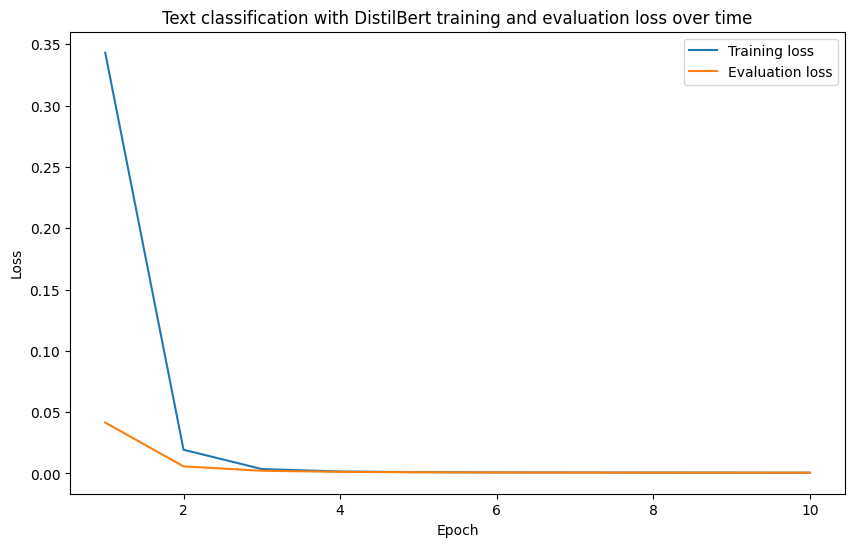

In [116]:
# plot training and evaluation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(trainer_history_training_df["epoch"], trainer_history_training_df["loss"], label="Training loss")
plt.plot(trainer_history_eval_df["epoch"], trainer_history_eval_df["eval_loss"], label="Evaluation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text classification with DistilBert training and evaluation loss over time")
plt.legend()
plt.show()

make predictions with: https://huggingface.co/docs/transformers/v4.40.2/en/main_classes/trainer#transformers.Trainer.predict

In [117]:
# perform predictions on the test set
predictions_all = trainer.predict(tokenized_dataset["test"])
prediction_values = predictions_all.predictions
prediction_metrics = predictions_all.metrics

print(f"[INFO] Prediction metrics on the test data:")
prediction_metrics

[INFO] Prediction metrics on the test data:


{'test_loss': 0.0006161202327348292,
 'test_accuracy': 1.0,
 'test_runtime': 0.0912,
 'test_samples_per_second': 548.428,
 'test_steps_per_second': 21.937}

torch.softmax: https://docs.pytorch.org/docs/2.12/generated/torch.nn.Softmax.html

torch.argmax: https://docs.pytorch.org/docs/2.12/generated/torch.argmax.html

np.argmax: https://numpy.org/doc/stable/reference/generated/numpy.argmax.html

accuracy score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

In [118]:
import torch
from sklearn.metrics import accuracy_score

# get prediction probabilities
pred_probs = torch.softmax(torch.tensor(prediction_values), dim=1)

# get the predicted labels
pred_labels = torch.argmax(pred_probs, dim=1)

# get the true labels
true_labels = dataset["test"]["label"]

# compare predicted labels to true labels to get the test accuracy
test_accuracy = accuracy_score(y_true=true_labels,
                               y_pred=pred_labels)

print(f"[INFO] Test accuracy: {test_accuracy*100}%")

[INFO] Test accuracy: 100.0%


In [119]:
# make a DataFrame of test predictions
test_predictions_df = pd.DataFrame({
    "text": dataset["test"]["text"],
    "true_label": true_labels,
    "pred_label": pred_labels,
    "pred_prob": torch.max(pred_probs, dim=1).values
})

test_predictions_df.head()

,text,true_label,pred_label,pred_prob
0,A slice of pepperoni pizza with a layer of mel...,1,1,0.999387
1,Red brick fireplace with a mantel serving as a...,0,0,0.999655
2,A bowl of sliced bell peppers with a sprinkle ...,1,1,0.999390
3,Set of mugs hanging on a hook,0,0,0.999678
4,Standing floor lamp providing light next to an...,0,0,0.999657


## How to Improve Model Prediction Accuracy

To make the model predict more accurately and with higher confidence, especially in cases where it's uncertain (like the 'tractor' example), here are some common strategies:

1.  **More Diverse and Labeled Data**: The most impactful improvement usually comes from training on a larger and more diverse dataset. If the model hasn't seen enough examples of 'not_food' items that are visually distinct from 'food' items, it might struggle to generalize.
    *   **Action**: Collect more image captions for both 'food' and 'not_food' categories, focusing on edge cases or ambiguous examples.

2.  **Data Augmentation**: Even with a limited dataset, you can create synthetic variations of your existing data to increase its effective size. For text, this could involve:
    *   **Action**: Using techniques like synonym replacement, random insertion/deletion/swapping of words, or back-translation (translate to another language and back).

3.  **Hyperparameter Tuning**: Experimenting with the training parameters can sometimes yield better results.
    *   **Action**: Try different `learning_rate` values (e.g., smaller learning rates like `1e-5`, `5e-6`), more `num_train_epochs`, or adjusting `per_device_train_batch_size`.

4.  **Different Model Architectures**: While `DistilBERT` is efficient, a larger model might capture more nuanced features.
    *   **Action**: Experiment with other pre-trained models from the Hugging Face Hub, such as `BERT-base-uncased`, `RoBERTa-base`, or even larger variants if computational resources allow.

5.  **Fine-tuning Longer**: Sometimes models need more training time to fully converge and learn the intricate patterns in the data.
    *   **Action**: Increase the `num_train_epochs` (e.g., from 10 to 20 or more) and monitor the training and evaluation loss to ensure it's not overfitting.

6.  **Addressing Class Imbalance**: Although your dataset is balanced (125 food, 125 not_food), if the new data you introduce becomes imbalanced, the model might favor the majority class.
    *   **Action**: If future datasets are imbalanced, consider techniques like oversampling the minority class, undersampling the majority class, or using class weights during training.

7.  **Error Analysis**: Manually inspect more examples where the model makes incorrect or low-confidence predictions. This can help you identify patterns in the errors and guide your data collection or augmentation efforts.
    *   **Action**: Review the `test_predictions_df` for texts where `pred_label` is wrong, or `pred_prob` is close to 0.5, to understand why the model struggled.

In [120]:
local_model_path = "/content/models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased"

MAKE PREDICTIONS WITH

pipeline mode for prediction: https://huggingface.co/docs/transformers/v4.42.0/en/main_classes/pipelines#pipelines



In [121]:
def set_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    return device

DEVICE = set_device()
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


In [122]:
trainer.train()
trainer.save_model(local_model_path)
tokenizer.save_pretrained(local_model_path)

Epoch,Training Loss,Validation Loss,Accuracy
1,0.000505,0.000492,1.000000
2,0.000470,0.000407,1.000000
3,0.000349,0.000349,1.000000
4,0.000312,0.000308,1.000000
5,0.000293,0.000279,1.000000
6,0.000256,0.000258,1.000000
7,0.000254,0.000243,1.000000
8,0.000239,0.000233,1.000000
9,0.000217,0.000227,1.000000
10,0.000223,0.000225,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased/tokenizer_config.json',
 '/content/models/learn_hf_food_not_food_text_classifier-distilbert-base-uncased/tokenizer.json')

In [123]:
import torch
from transformers import pipeline

BATCH_SIZE = 32

# create an instance of transformers.pipeline
food_not_food_classifier = pipeline(task="text-classification",
                                    model=local_model_path,
                                    device=DEVICE,
                                    top_k=1,
                                    batch_size=BATCH_SIZE)

food_not_food_classifier

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

TextClassificationPipeline: {'model': 'DistilBertForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [132]:
# test model on some example text
sample_text_food = "A delicious photo of a plate of scrambled eggs"
food_not_food_classifier(sample_text_food)

[[{'label': 'food', 'score': 0.9997124075889587}]]

In [133]:
# test model on some example text
sample_text_food = "Ben is a fat chud that eats pizza and cookies everyday"
food_not_food_classifier(sample_text_food)

[[{'label': 'food', 'score': 0.999782383441925}]]

In [128]:
# test model on some example text
sample_text_not_food = "A delicious photo of a plate"
food_not_food_classifier(sample_text_not_food)

[[{'label': 'not_food', 'score': 0.9996623992919922}]]

In [129]:
# test model on some example text
sample_text_not_food = "Driving in an infinity is so tough"
food_not_food_classifier(sample_text_not_food)

[[{'label': 'not_food', 'score': 0.9997977614402771}]]

In [134]:
# Pass in random text to the model
food_not_food_classifier("cvnhertiejhwgdjshdfgh394587")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


[[{'label': 'not_food', 'score': 0.9993079900741577}]]

In [135]:
BATCH_SIZE = 32

food_not_food_classifier = pipeline(task="text-classification",
                                    model=local_model_path,
                                    batch_size=BATCH_SIZE,
                                    device=DEVICE)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [140]:
"""
seems to work pretty well and in the case of labeling something as food even though it's not, it's accuracy is lower which makes sense
"""
# Create a list of sentences to make predictions on
sentences = [
    "I whipped up a fresh batch of code, but it seems to have a syntax error.",
    "The new software is definitely a spicy upgrade, taking some time to get used to.",
    "Her social media post was the perfect recipe for a viral sensation.",
    "He served up a rebuttal full of facts, leaving his opponent speechless.",
    "The team needs to simmer down a bit before tackling the next challenge.",
    "The presentation was a delicious blend of humor and information, keeping the audience engaged.",
    "My favoruite food is chicken!",
    "protein pasta with noodles is fire"
]

food_not_food_classifier(sentences)

[{'label': 'not_food', 'score': 0.979710578918457},
 {'label': 'food', 'score': 0.6609016060829163},
 {'label': 'not_food', 'score': 0.9996411800384521},
 {'label': 'not_food', 'score': 0.9993554949760437},
 {'label': 'not_food', 'score': 0.9966707825660706},
 {'label': 'not_food', 'score': 0.8030661940574646},
 {'label': 'food', 'score': 0.9997413754463196},
 {'label': 'food', 'score': 0.9997560381889343}]

In [142]:
# check timing
import time

# Create 800 sentences
sentences_800 = sentences * 100

# Time how long it takes to make predictions on all sentences (one at a time)
print(f"[INFO] Number of sentences: {len(sentences_800)}")
start_time_one_at_a_time = time.time()
for sentence in sentences_800:
    food_not_food_classifier(sentence)
end_time_one_at_a_time = time.time()

print(f"[INFO] Time taken for one at a time prediction: {end_time_one_at_a_time - start_time_one_at_a_time} seconds")
print(f"[INFO] Avg inference time per sentence: {(end_time_one_at_a_time - start_time_one_at_a_time) / len(sentences_800)} seconds")

[INFO] Number of sentences: 800
[INFO] Time taken for one at a time prediction: 6.0473573207855225 seconds
[INFO] Avg inference time per sentence: 0.007559196650981903 seconds


In [143]:
# testing the timing with batching
for i in [10, 100, 1000, 10_000]:
    sentences_big = sentences * i
    print(f"[INFO] Number of sentences: {len(sentences_big)}")

    start_time = time.time()
    # Predict on all sentences in batches
    food_not_food_classifier(sentences_big)
    end_time = time.time()

    print(f"[INFO] Inference time for {len(sentences_big)} sentences: {round(end_time - start_time, 5)} seconds.")
    print(f"[INFO] Avg inference time per sentence: {round((end_time - start_time) / len(sentences_big), 8)} seconds.")
    print()

[INFO] Number of sentences: 80
[INFO] Inference time for 80 sentences: 0.10673 seconds.
[INFO] Avg inference time per sentence: 0.00133417 seconds.

[INFO] Number of sentences: 800
[INFO] Inference time for 800 sentences: 0.85595 seconds.
[INFO] Avg inference time per sentence: 0.00106994 seconds.

[INFO] Number of sentences: 8000
[INFO] Inference time for 8000 sentences: 7.86298 seconds.
[INFO] Avg inference time per sentence: 0.00098287 seconds.

[INFO] Number of sentences: 80000
[INFO] Inference time for 80000 sentences: 69.88839 seconds.
[INFO] Avg inference time per sentence: 0.0008736 seconds.



from above we can see that batching allows to run more samples at once and runs faster than individually going through samples